In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/"

import os
os.chdir(r"C:\Z")  # Cambia el directorio de trabajo
print(os.getcwd())  # Verifica que cambió correctamente

C:\Z


In [2]:
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
import os

num_points = 5000  # Número de puntos en cada espectro, muy importante utilizar el modelo, pues se usará para interpolar los datos que le pasamos

# Cargar los datos
data_file = r'TFGF/Python/storage/spectra_data.pkl'
with open(data_file, 'rb') as f:
    spectra_data = pickle.load(f)

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# En lugar de concatenar, apilamos para formar dos canales: uno para el flujo y otro para la longitud de onda.
X = np.stack([fluxes, wavelengths], axis=1)  # Forma: (num_samples, 2, num_points)
y = np.array(redshifts)

# Normalización (se normaliza cada muestra aplanada y luego se reestructura)
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(nsamples, nchannels, npoints)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Definición del modelo que combina CNN y atención para resaltar las líneas de emisión
class AttentionCNN(nn.Module):
    def __init__(self, num_points):
        super(AttentionCNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Tras tres capas de pooling, la longitud se reduce en un factor de 8
        self.seq_length = num_points // 8  # nueva dimensión temporal
        self.embed_dim = 64  # número de canales tras la CNN

        # Módulo de atención: se utiliza self-attention sobre la secuencia de características
        self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)

        # Capas finales para la regresión del redshift
        self.fc = nn.Sequential(
            nn.Linear(self.embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x tiene forma (batch_size, 2, num_points)
        features = self.cnn(x)            # Forma: (batch_size, 64, seq_length)
        features = features.permute(0, 2, 1)  # Reordenar a (batch_size, seq_length, embed_dim)
        # Aplicar atención self-attention: se usan las mismas características como query, key y value
        attn_output, _ = self.attention(features, features, features)
        # Agregación global mediante promedio sobre la dimensión secuencial
        pooled = attn_output.mean(dim=1)  # Forma: (batch_size, embed_dim)
        out = self.fc(pooled)
        return out

# Configuración para utilizar GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Instanciar el modelo y moverlo a GPU
modelAttentionCNN = AttentionCNN(num_points).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelAttentionCNN.parameters(), lr=0.00001)

Usando dispositivo: cuda


In [3]:
# Entrenamiento
num_epochs = 1000
for epoch in range(num_epochs):
    modelAttentionCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        # Mover los datos al dispositivo (GPU si está disponible)
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelAttentionCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    modelAttentionCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            # Mover los datos al dispositivo
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelAttentionCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

# Evaluación con MAE
mae_loss = nn.L1Loss()
modelAttentionCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Mover los datos al dispositivo
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelAttentionCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio (MAE) en el conjunto de prueba: {test_mae:.4f}")

# Guardar modelo y scaler
output_dir = r'TFGF/Python/storage'
model_file_path = os.path.join(output_dir, 'modelAttentionCNN.pth')
scaler_file_path = os.path.join(output_dir, 'scalerAttentionCNN.pkl')

torch.save(modelAttentionCNN.state_dict(), model_file_path)
with open(scaler_file_path, 'wb') as f:
    pickle.dump(scaler, f)

Epoch 1/1000, Loss: 0.2367, Val Loss: 0.1700
Epoch 2/1000, Loss: 0.0877, Val Loss: 0.0256
Epoch 3/1000, Loss: 0.0195, Val Loss: 0.0162
Epoch 4/1000, Loss: 0.0150, Val Loss: 0.0142
Epoch 5/1000, Loss: 0.0136, Val Loss: 0.0133
Epoch 6/1000, Loss: 0.0129, Val Loss: 0.0129
Epoch 7/1000, Loss: 0.0125, Val Loss: 0.0126
Epoch 8/1000, Loss: 0.0123, Val Loss: 0.0124
Epoch 9/1000, Loss: 0.0122, Val Loss: 0.0123
Epoch 10/1000, Loss: 0.0121, Val Loss: 0.0123
Epoch 11/1000, Loss: 0.0121, Val Loss: 0.0122
Epoch 12/1000, Loss: 0.0120, Val Loss: 0.0122
Epoch 13/1000, Loss: 0.0120, Val Loss: 0.0122
Epoch 14/1000, Loss: 0.0120, Val Loss: 0.0122
Epoch 15/1000, Loss: 0.0120, Val Loss: 0.0122
Epoch 16/1000, Loss: 0.0120, Val Loss: 0.0123
Epoch 17/1000, Loss: 0.0120, Val Loss: 0.0122
Epoch 18/1000, Loss: 0.0119, Val Loss: 0.0122
Epoch 19/1000, Loss: 0.0119, Val Loss: 0.0122
Epoch 20/1000, Loss: 0.0119, Val Loss: 0.0122
Epoch 21/1000, Loss: 0.0119, Val Loss: 0.0121
Epoch 22/1000, Loss: 0.0119, Val Loss: 0.01

In [4]:
# # Cargar el modelo

# # Definir el directorio de destino
# output_dir = r'TFGF/Python/storage'
# model_file_path = os.path.join(output_dir, 'modelAttentionCNN.pth')
# scaler_file_path = os.path.join(output_dir, 'scalerAttentionCNN.pkl')

# modelAttentionCNN = AttentionCNN(num_points)
# modelAttentionCNN.load_state_dict(torch.load(model_file_path))

# with open(scaler_file_path, 'rb') as f:
#     scaler = pickle.load(f)

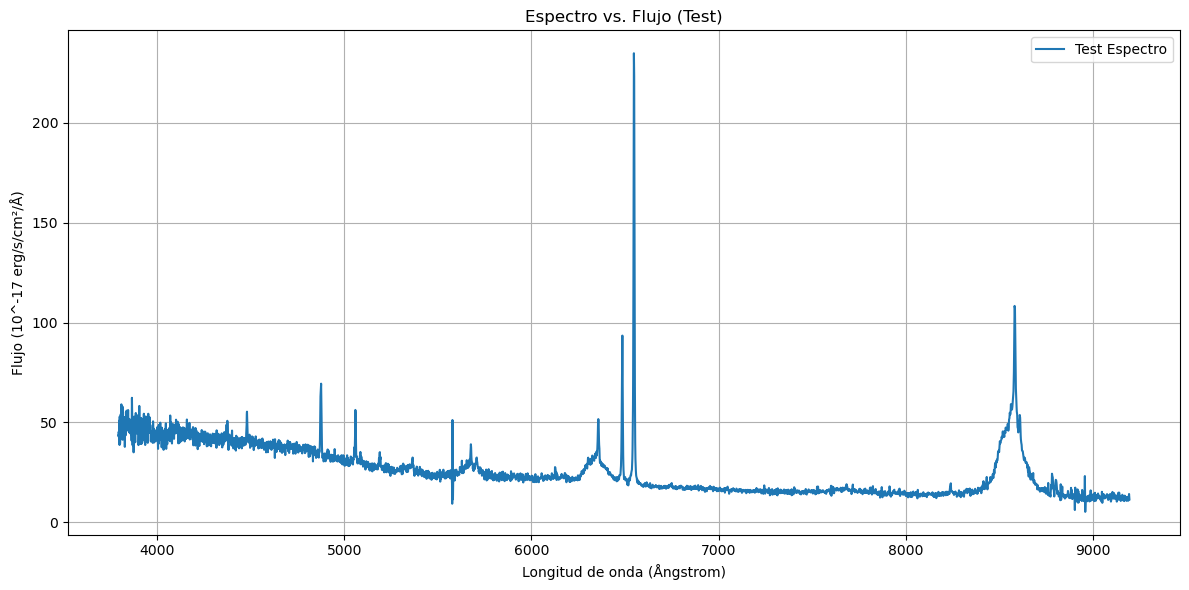

Redshift predicho: 0.47687673568725586
Redshift real: [0.30719927]


In [8]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
import torch

file_path = r'TFGF/Python/spectrums/spec-0293-51689-0091.fits'
with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"]

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertimos a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)

    # Continuamos insertando hasta alcanzar el número deseado de puntos
    while len(wl) < target_count:
        # Calcular las diferencias absolutas en flux entre puntos consecutivos
        diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl) - 1)]
        # Encontrar el índice donde la diferencia es máxima
        max_idx = np.argmax(diffs)
        # Interpolar linealmente para obtener un nuevo punto
        new_wl = (wl[max_idx] + wl[max_idx+1]) / 2
        new_fl = (fl[max_idx] + fl[max_idx+1]) / 2
        # Insertar el nuevo punto en la posición correspondiente
        wl.insert(max_idx+1, new_wl)
        fl.insert(max_idx+1, new_fl)

    return np.array(wl), np.array(fl)

# Ampliar los puntos hasta obtener 5000 en total
test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=5000)

# Asegurar que test_flux y test_wavelength sean numpy arrays
test_flux = np.array(test_flux)
test_wavelength = np.array(test_wavelength)

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Preprocesamiento para el modelo:
# Apilar los dos canales: flujo y longitud de onda, de forma (1, 2, 5000)
x_test = np.stack([test_flux, test_wavelength], axis=0)  # forma (2, 5000)
x_test = x_test.reshape(1, -1)  # aplanamos a (1, 10000)

# Aplicar la normalización (se asume que 'scaler' ya ha sido definido previamente)
x_test = scaler.transform(x_test)
x_test = x_test.reshape(1, 2, 5000)

# Convertir a tensor
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

# Mover el tensor al dispositivo (GPU si está disponible)
x_test_tensor = x_test_tensor.to(device)

# Inferencia con el modelo (se asume que 'modelAttentionCNN' ya se encuentra en GPU)
with torch.no_grad():
    predicted_redshift = modelAttentionCNN(x_test_tensor)

print("Redshift predicho:", predicted_redshift.item())
print("Redshift real:", test_redshift)